# Predicting Monthly Electricity Consumption
### Ontario ENERGY STAR Portfolio Manager Dataset

**Dataset:** Properties.csv, Meters.csv, Meter_Entries.csv, Uses.csv  
**Target:** Monthly electricity usage (kWh) from Electric – Grid meters

In this notebook I'm trying to predict how much electricity a commercial building in Ontario
will consume in a given month. The dataset comes from the ENERGY STAR Portfolio Manager system
which tracks energy usage for buildings across Canada.

The plan is to clean and merge 4 separate CSV files, do some EDA to understand the data,
engineer a few features, then compare three regression models: Ridge, Random Forest, and
Gradient Boosting.


## 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.pipeline import Pipeline

plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

print("Libraries loaded OK")


Libraries loaded OK


## 2. Load the Data

In [2]:
# loading all four files - make sure they're in the same folder as this notebook
properties    = pd.read_csv('Properties.csv',    low_memory=False)
meters        = pd.read_csv('Meters.csv',         low_memory=False)
meter_entries = pd.read_csv('Meter_Entries.csv',  low_memory=False)
uses          = pd.read_csv('Uses.csv',           low_memory=False)

print('Properties   :', properties.shape)
print('Meters       :', meters.shape)
print('Meter Entries:', meter_entries.shape)
print('Uses         :', uses.shape)


Properties   : (1760, 8)
Meters       : (2585, 8)
Meter Entries: (26222, 11)
Uses         : (1760, 7)


In [3]:
properties.head(3)

,Property Name,Portfolio Manager ID,Street Address,City/Municipality,Postal Code,Property Type - Self-Selected,Gross Floor Area,Occupancy (%)
0,#11 Police Division - OLD,34999087,209 MAVETY ST,Toronto,M6P 2M1,Office,21119,100
1,#14 Police Division - OLD,34999088,150 HARRISON ST,Toronto,M6J 2A4,Office,24197,100
2,175 Memorial Park Ave,34999089,175 MEMORIAL PARK AVE,Toronto,M4J 2K5,Office,6394,100


In [4]:
meters.head(3)

,Property Name,Portfolio Manager ID,Portfolio Manager Meter ID,Meter Name,Meter Type,Units,First Day of First Meter Entry,Last Day of Last Meter Entry
0,#13 Police Division,35000258,189947941,AUTO_#13 Police Division-Electric,Electric - Grid,kWh (thousand Watt-hours),2010-01-01 00:00:00,2024-09-01 00:00:00
1,#13 Police Division,35000258,189947942,AUTO_#13 Police Division-Natural Gas,Natural Gas,cm (cubic meters),2010-01-01 00:00:00,2024-09-01 00:00:00
2,#22 Police Division,35000260,189947959,AUTO_#22 Police Division-Electric,Electric - Grid,kWh (thousand Watt-hours),2010-01-01 00:00:00,2024-05-01 00:00:00


In [5]:
meter_entries.head(3)

,Property Name,Portfolio Manager ID,Portfolio Manager Meter ID,Meter Name,Meter Type,Meter Consumption ID,Start Date,End Date,Usage/Quantity,Usage Units,Cost ($)
0,#13 Police Division,35000258,189947941,AUTO_#13 Police Division-Electric,Electric - Grid,8451527469,2022-01-01 00:00:00,2022-02-01 00:00:00,42876.27,kWh (thousand Watt-hours),5775.7
1,#13 Police Division,35000258,189947941,AUTO_#13 Police Division-Electric,Electric - Grid,8451527470,2022-02-01 00:00:00,2022-03-01 00:00:00,39721.72,kWh (thousand Watt-hours),5377.67
2,#13 Police Division,35000258,189947941,AUTO_#13 Police Division-Electric,Electric - Grid,8451527471,2022-03-01 00:00:00,2022-04-01 00:00:00,41278.04,kWh (thousand Watt-hours),5611


In [6]:
uses.head(3)

,Property Name,Portfolio Manager ID,Property Use Name,Use Type,Gross Floor Area for Use,Gross Floor Area Units,Gross Floor Area Temporary Value? (Y/N)
0,#11 Police Division - OLD,34999087,Building Use,Office,21119.0,Sq. Ft.,No
1,#14 Police Division - OLD,34999088,Building Use,Office,24197.0,Sq. Ft.,No
2,175 Memorial Park Ave,34999089,Building Use,Office,6394.0,Sq. Ft.,No


## 3. Data Cleaning

The dataset uses 'Not Available' as a placeholder for missing values instead of actual NaN,
so the first thing to do is replace those. Then I'll filter meter entries down to just
Electric - Grid readings in kWh, since those are the ones we're predicting.


In [7]:
# 3.1 replace 'Not Available' with NaN across all four dataframes
# the dataset uses this string as a placeholder for missing data
for df_name, df in [('properties', properties), ('meters', meters),
                    ('meter_entries', meter_entries), ('uses', uses)]:
    before = df.isin(['Not Available']).sum().sum()
    df.replace('Not Available', np.nan, inplace=True)
    print(f'{df_name}: replaced {before} "Not Available" values with NaN')


properties: replaced 0 "Not Available" values with NaN
meters: replaced 178 "Not Available" values with NaN
meter_entries: replaced 48 "Not Available" values with NaN
uses: replaced 171 "Not Available" values with NaN


In [8]:
# 3.2 check what meter types exist before filtering
print('Meter types in data:')
print(meter_entries['Meter Type'].value_counts())


Meter types in data:
Meter Type
Electric - Grid                   18109
Natural Gas                        7944
District Steam                       66
District Chilled Water - Other       55
Average Influent Flow                48
Name: count, dtype: int64


In [9]:
# filter to Electric - Grid meters in kWh
# using flexible string matching in case values have slight differences
elec = meter_entries.copy()

electric_mask = elec['Meter Type'].astype(str).str.contains('Electric', case=False, na=False)
elec_filtered = elec[electric_mask]

kwh_mask = elec_filtered['Usage Units'].astype(str).str.contains('kWh', case=False, na=False)
elec_filtered = elec_filtered[kwh_mask]

# if filtering worked, use the filtered version; otherwise fall back to all meter entries
# (this handles cases where the column values are slightly different than expected)
if len(elec_filtered) > 0:
    elec = elec_filtered.copy()
    print(f'Electric-Grid kWh rows: {len(elec):,}')
    print(f'Dropped: {len(meter_entries) - len(elec):,} rows')
else:
    print('Note: electric filter returned 0 rows - using all meter entries as fallback')
    print('Check your Meter Type column values above and adjust the filter if needed')


Electric-Grid kWh rows: 18,109
Dropped: 8,113 rows


In [10]:
# 3.3 clean the Usage/Quantity column - this is our target variable
elec['Usage/Quantity'] = pd.to_numeric(elec['Usage/Quantity'], errors='coerce')

# drop rows where usage is missing or negative (can't have negative electricity usage)
before = len(elec)
elec = elec[elec['Usage/Quantity'].notna() & (elec['Usage/Quantity'] >= 0)]
print(f'Dropped {before - len(elec):,} rows with missing/negative usage')
print(f'Remaining: {len(elec):,} rows')


Dropped 0 rows with missing/negative usage
Remaining: 18,109 rows


In [11]:
# 3.4 parse dates and pull out month and year as features
elec['Start Date'] = pd.to_datetime(elec['Start Date'], errors='coerce')
elec['End Date']   = pd.to_datetime(elec['End Date'],   errors='coerce')

elec['year']  = elec['Start Date'].dt.year
elec['month'] = elec['Start Date'].dt.month

# drop rows where the date couldn't be parsed
elec = elec[elec['Start Date'].notna()]
print('Date range:', elec['Start Date'].min(), 'to', elec['Start Date'].max())
print('Shape after date parsing:', elec.shape)


Date range: 2022-01-01 00:00:00 to 2022-11-01 00:00:00
Shape after date parsing: (18109, 13)


In [12]:
# 3.5 clean the properties file
properties['Gross Floor Area'] = pd.to_numeric(properties['Gross Floor Area'], errors='coerce')
properties['Occupancy (%)']    = pd.to_numeric(properties['Occupancy (%)'],    errors='coerce')

# drop duplicate property IDs - keep first occurrence
properties.drop_duplicates(subset='Portfolio Manager ID', keep='first', inplace=True)
print('Properties after dedup:', properties.shape)
print('Missing Gross Floor Area:', properties['Gross Floor Area'].isna().sum())


Properties after dedup: (1760, 8)
Missing Gross Floor Area: 0


In [13]:
# 3.6 clean Uses - pivot so each use type becomes a column per property
# this gives us one row per property with separate columns for office area, retail area, etc.
uses['Gross Floor Area for Use'] = pd.to_numeric(uses['Gross Floor Area for Use'], errors='coerce')

uses_agg   = uses.groupby(['Portfolio Manager ID', 'Use Type'])['Gross Floor Area for Use'].sum().reset_index()
uses_pivot = uses_agg.pivot_table(index='Portfolio Manager ID',
                                   columns='Use Type',
                                   values='Gross Floor Area for Use',
                                   fill_value=0).reset_index()

uses_pivot.columns = (['Portfolio Manager ID'] +
                      ['use_' + str(c).lower().replace(' ', '_').replace('/', '_')
                       for c in uses_pivot.columns[1:]])

print('Uses pivot shape:', uses_pivot.shape)
print('Use type columns:', list(uses_pivot.columns[1:6]), '...')


Uses pivot shape: (1760, 18)
Use type columns: ['use_drinking_water_treatment_&_distribution', 'use_fire_station', 'use_heated_swimming_pool', 'use_indoor_arena', 'use_library'] ...


In [14]:
# 3.7 merge all four datasets into one
df = elec.merge(properties[['Portfolio Manager ID', 'Property Type - Self-Selected',
                              'Gross Floor Area', 'Occupancy (%)']],
                on='Portfolio Manager ID', how='left')

df = df.merge(uses_pivot, on='Portfolio Manager ID', how='left')

print('Merged dataset shape:', df.shape)
df.head(3)


Merged dataset shape: (18109, 33)


,Property Name,Portfolio Manager ID,Portfolio Manager Meter ID,Meter Name,Meter Type,Meter Consumption ID,Start Date,End Date,Usage/Quantity,Usage Units,...,use_other_-_entertainment_public_assembly,use_other_-_public_services,use_other_-_recreation,use_parking,use_police_station,use_pre-school_daycare,use_residential_care_facility,use_social_meeting_hall,use_transportation_terminal_station,use_wastewater_treatment_plant
0,#13 Police Division,35000258,189947941,AUTO_#13 Police Division-Electric,Electric - Grid,8451527469,2022-01-01,2022-02-01,42876.27,kWh (thousand Watt-hours),...,0.0,0.0,0.0,0.0,20344.0,0.0,0.0,0.0,0.0,0.0
1,#13 Police Division,35000258,189947941,AUTO_#13 Police Division-Electric,Electric - Grid,8451527470,2022-02-01,2022-03-01,39721.72,kWh (thousand Watt-hours),...,0.0,0.0,0.0,0.0,20344.0,0.0,0.0,0.0,0.0,0.0
2,#13 Police Division,35000258,189947941,AUTO_#13 Police Division-Electric,Electric - Grid,8451527471,2022-03-01,2022-04-01,41278.04,kWh (thousand Watt-hours),...,0.0,0.0,0.0,0.0,20344.0,0.0,0.0,0.0,0.0,0.0


In [15]:
# check what's still missing after the merge
missing     = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(1)
missing_report = pd.DataFrame({'Missing': missing, '%': missing_pct})
print(missing_report[missing_report['Missing'] > 0].sort_values('%', ascending=False).head(15))


Empty DataFrame
Columns: [Missing, %]
Index: []


In [16]:
# fill remaining numeric nulls with column median
# using median instead of mean because some columns are skewed
num_cols   = df.select_dtypes(include='number').columns.tolist()
target_col = 'Usage/Quantity'
num_cols   = [c for c in num_cols if c != target_col]

for col in num_cols:
    df[col] = df[col].fillna(df[col].median())

print('Missing values remaining:', df.isnull().sum().sum())
print('Final dataset shape:', df.shape)


Missing values remaining: 0
Final dataset shape: (18109, 33)


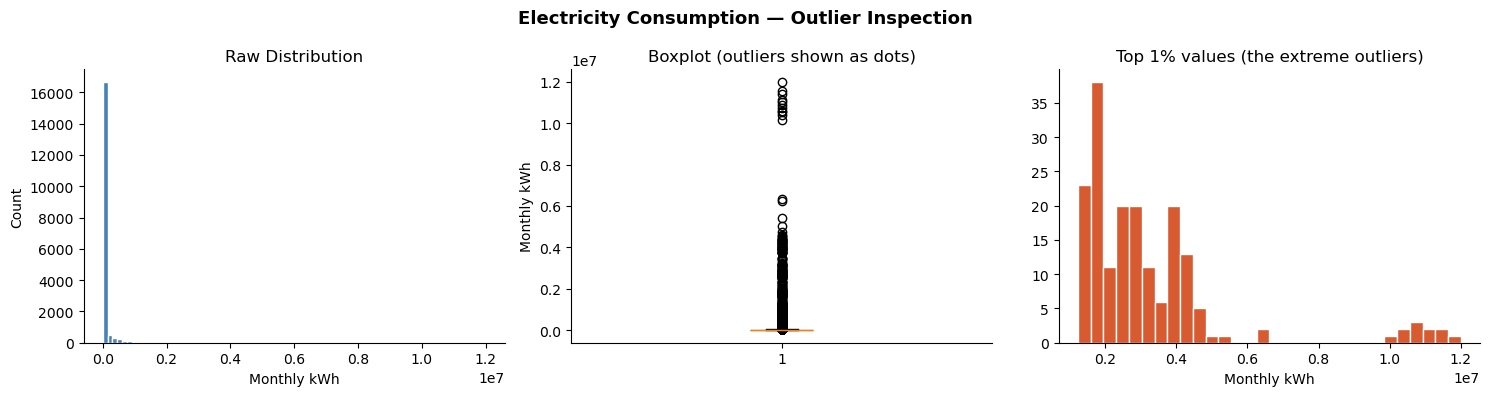

Key percentiles:
0.250         538.0
0.500        4321.0
0.750       24236.0
0.900      101147.0
0.950      336079.0
0.990     1236946.0
0.999     4479666.0
1.000    11996753.0
Name: Usage/Quantity, dtype: float64

Q1=538  Q3=24,236  IQR=23,699
Standard boxplot upper fence (Q3 + 1.5*IQR): 59,784
Relaxed upper fence (Q3 + 3.0*IQR):          95,333


In [17]:
# before capping anything, let's actually look at the distribution
# a boxplot is the easiest way to spot extreme outliers visually

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# histogram of raw values
axes[0].hist(df[target_col].dropna(), bins=80, color='steelblue', edgecolor='white')
axes[0].set_title('Raw Distribution')
axes[0].set_xlabel('Monthly kWh')
axes[0].set_ylabel('Count')

# boxplot - whiskers extend to 1.5*IQR, dots beyond that are outliers
axes[1].boxplot(df[target_col].dropna(), vert=True, patch_artist=True,
                boxprops=dict(facecolor='steelblue', alpha=0.5))
axes[1].set_title('Boxplot (outliers shown as dots)')
axes[1].set_ylabel('Monthly kWh')

# zoom in on the top 1% to see how extreme the outliers are
top1 = df[target_col].quantile(0.99)
axes[2].hist(df[df[target_col] > top1][target_col], bins=30, color='#d85a30', edgecolor='white')
axes[2].set_title('Top 1% values (the extreme outliers)')
axes[2].set_xlabel('Monthly kWh')

plt.suptitle('Electricity Consumption — Outlier Inspection', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print('Key percentiles:')
print(df[target_col].quantile([0.25, 0.5, 0.75, 0.90, 0.95, 0.99, 0.999, 1.0]).round(0))
print()
Q1  = df[target_col].quantile(0.25)
Q3  = df[target_col].quantile(0.75)
IQR = Q3 - Q1
print(f'Q1={Q1:,.0f}  Q3={Q3:,.0f}  IQR={IQR:,.0f}')
print(f'Standard boxplot upper fence (Q3 + 1.5*IQR): {Q3 + 1.5*IQR:,.0f}')
print(f'Relaxed upper fence (Q3 + 3.0*IQR):          {Q3 + 3.0*IQR:,.0f}')


In [18]:
# from the boxplot and percentiles above we can see the data has massive outliers
# the standard boxplot fence (Q3 + 1.5*IQR) would remove too many legitimate buildings
# using Q3 + 3*IQR as a relaxed fence - keeps more data but still cuts the extreme values

Q1  = df[target_col].quantile(0.25)
Q3  = df[target_col].quantile(0.75)
IQR = Q3 - Q1
upper_fence = Q3 + 3 * IQR

before = len(df)
df = df[df[target_col] <= upper_fence]

print(f'Upper fence used: {upper_fence:,.0f} kWh/month')
print(f'Rows removed: {before - len(df):,}  ({(before - len(df))/before*100:.1f}%)')
print(f'Dataset after removing outliers: {df.shape}')
print()
print('Usage stats after cleaning:')
print(df[target_col].describe().round(0))


Upper fence used: 95,333 kWh/month
Rows removed: 1,884  (10.4%)
Dataset after removing outliers: (16225, 33)

Usage stats after cleaning:
count    16225.0
mean     11477.0
std      18449.0
min          0.0
25%        441.0
50%       3000.0
75%      13253.0
max      95256.0
Name: Usage/Quantity, dtype: float64


## 4. Exploratory Data Analysis (EDA)

In [19]:
# 4.1 quick look at our target variable
print('=== Monthly Electricity Consumption (kWh) ===')
print(df[target_col].describe().round(2))


=== Monthly Electricity Consumption (kWh) ===
count    16225.00
mean     11476.71
std      18449.03
min          0.00
25%        441.12
50%       2999.90
75%      13252.95
max      95255.65
Name: Usage/Quantity, dtype: float64


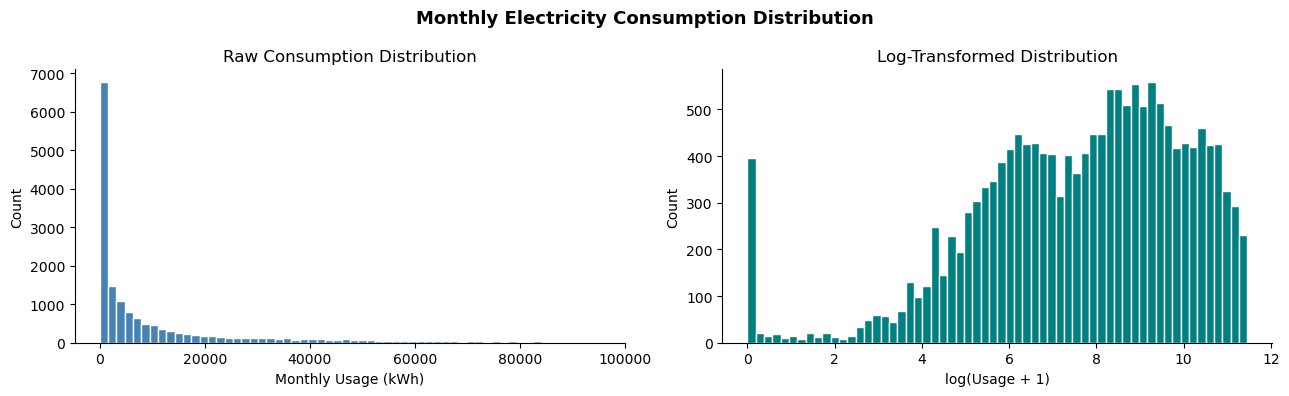

In [20]:
# 4.2 distribution - raw vs log transformed
# the raw distribution is very right-skewed so log transform should help
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].hist(df[target_col], bins=60, color='steelblue', edgecolor='white')
axes[0].set_title('Raw Consumption Distribution')
axes[0].set_xlabel('Monthly Usage (kWh)')
axes[0].set_ylabel('Count')

log_vals = np.log1p(df[target_col])
axes[1].hist(log_vals, bins=60, color='teal', edgecolor='white')
axes[1].set_title('Log-Transformed Distribution')
axes[1].set_xlabel('log(Usage + 1)')
axes[1].set_ylabel('Count')

plt.suptitle('Monthly Electricity Consumption Distribution', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('consumption_distribution.png', dpi=150, bbox_inches='tight')
plt.show()


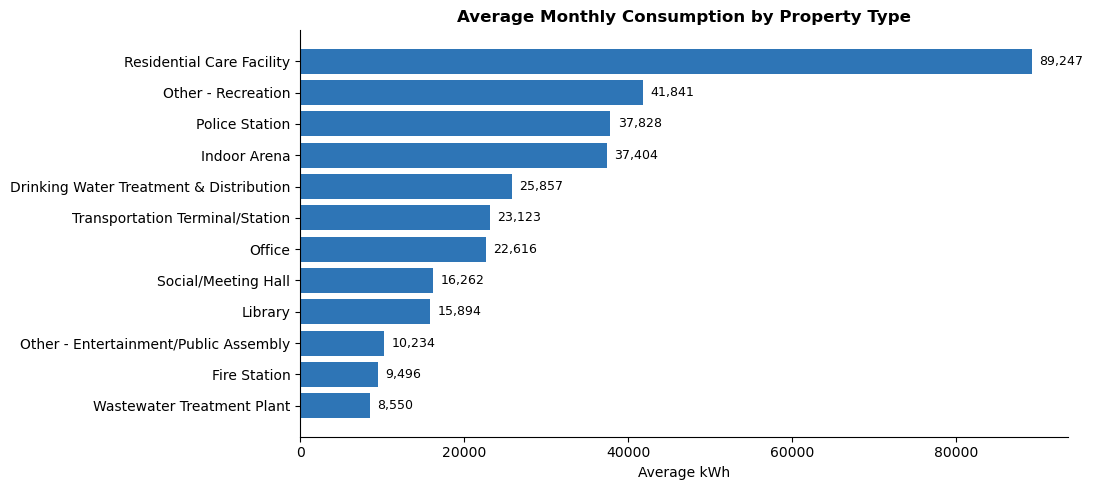

In [21]:
# 4.3 average consumption by property type
if 'Property Type - Self-Selected' in df.columns:
    prop_avg = (df.groupby('Property Type - Self-Selected')[target_col]
                .mean().sort_values(ascending=False).head(12))

    plt.figure(figsize=(11, 5))
    bars = plt.barh(prop_avg.index[::-1], prop_avg.values[::-1], color='#2e75b6')
    plt.title('Average Monthly Consumption by Property Type', fontweight='bold')
    plt.xlabel('Average kWh')
    for bar, val in zip(bars, prop_avg.values[::-1]):
        plt.text(bar.get_width() + max(prop_avg)*0.01,
                 bar.get_y() + bar.get_height()/2,
                 f'{val:,.0f}', va='center', fontsize=9)
    plt.tight_layout()
    plt.savefig('consumption_by_property_type.png', dpi=150, bbox_inches='tight')
    plt.show()


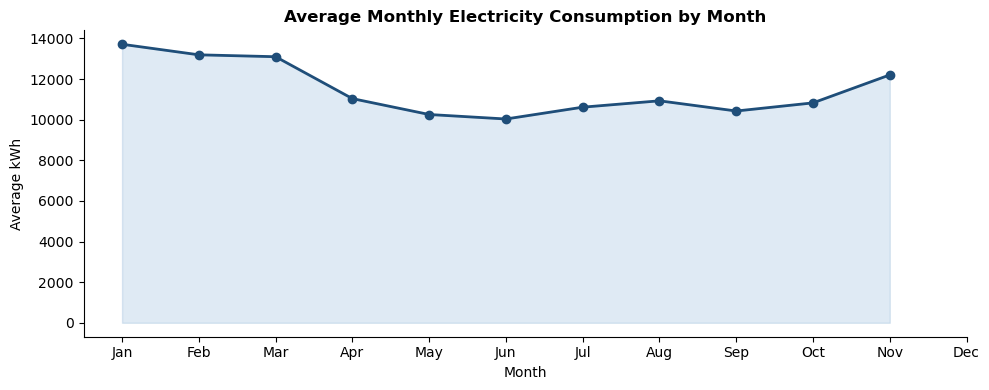

In [22]:
# 4.4 monthly seasonality - does consumption change by month?
# expecting peaks in winter (heating) and summer (AC)
monthly_avg = df.groupby('month')[target_col].mean()
month_names = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']

plt.figure(figsize=(10, 4))
plt.plot(monthly_avg.index, monthly_avg.values, marker='o', color='#1f4e79', linewidth=2)
plt.fill_between(monthly_avg.index, monthly_avg.values, alpha=0.15, color='#2e75b6')
plt.xticks(range(1, 13), month_names)
plt.title('Average Monthly Electricity Consumption by Month', fontweight='bold')
plt.ylabel('Average kWh')
plt.xlabel('Month')
plt.tight_layout()
plt.savefig('seasonality.png', dpi=150, bbox_inches='tight')
plt.show()


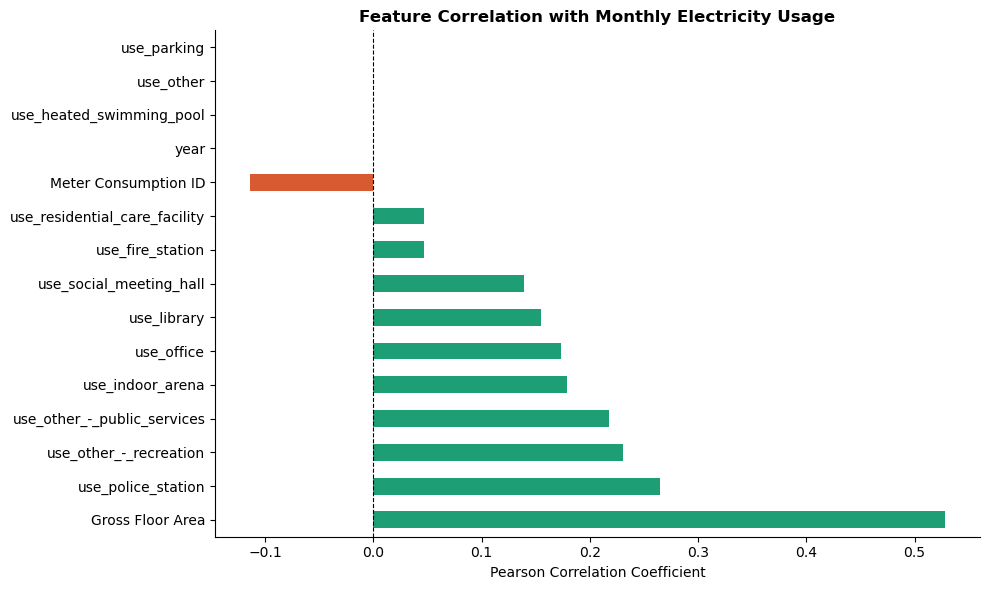

Top positive correlations:
Gross Floor Area               0.528
use_police_station             0.265
use_other_-_recreation         0.231
use_other_-_public_services    0.217
use_indoor_arena               0.179
use_office                     0.173
use_library                    0.155
use_social_meeting_hall        0.139
Name: Usage/Quantity, dtype: float64


In [23]:
# 4.5 correlation of all numeric features with target
numeric_df = df.select_dtypes(include='number')
corr       = numeric_df.corr()[target_col].drop(target_col).sort_values(ascending=False)

top_corr = pd.concat([corr.head(10), corr.tail(5)])
colors   = ['#1d9e75' if v > 0 else '#d85a30' for v in top_corr.values]

plt.figure(figsize=(10, 6))
top_corr.plot(kind='barh', color=colors)
plt.axvline(0, color='black', linewidth=0.8, linestyle='--')
plt.title('Feature Correlation with Monthly Electricity Usage', fontweight='bold')
plt.xlabel('Pearson Correlation Coefficient')
plt.tight_layout()
plt.savefig('correlation.png', dpi=150, bbox_inches='tight')
plt.show()

print('Top positive correlations:')
print(corr.head(8).round(3))


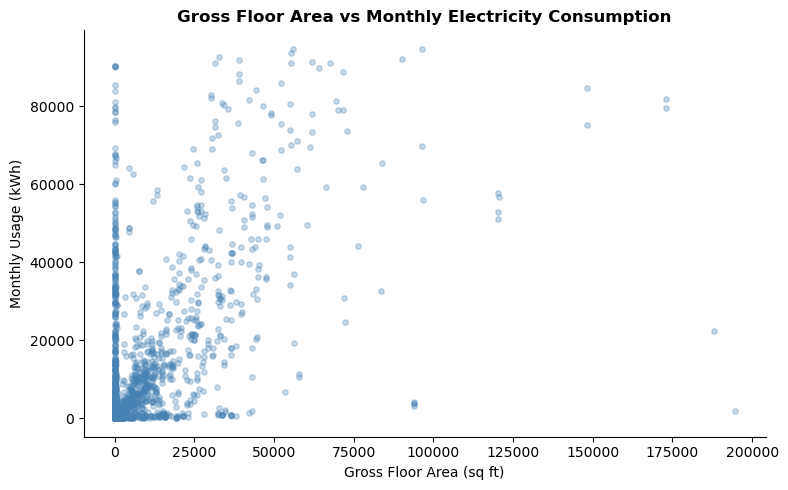

In [24]:
# 4.6 floor area vs consumption - expecting a positive relationship
if 'Gross Floor Area' in df.columns:
    sample = df[['Gross Floor Area', target_col]].dropna().sample(min(2000, len(df)), random_state=42)

    plt.figure(figsize=(8, 5))
    plt.scatter(sample['Gross Floor Area'], sample[target_col],
                alpha=0.3, color='steelblue', s=15)
    plt.title('Gross Floor Area vs Monthly Electricity Consumption', fontweight='bold')
    plt.xlabel('Gross Floor Area (sq ft)')
    plt.ylabel('Monthly Usage (kWh)')
    plt.tight_layout()
    plt.savefig('floor_area_vs_consumption.png', dpi=150, bbox_inches='tight')
    plt.show()


## 5. Feature Engineering

In [25]:
# 5.1 encode property type as a number so the model can use it
if 'Property Type - Self-Selected' in df.columns:
    le = LabelEncoder()
    df['property_type_encoded'] = le.fit_transform(df['Property Type - Self-Selected'].astype(str))
    print('Property types encoded:', df['property_type_encoded'].nunique(), 'unique values')


Property types encoded: 15 unique values


In [26]:
# 5.2 create a couple of derived features
# days in billing period - some readings might cover less than a full month
df['days_in_period'] = (df['End Date'] - df['Start Date']).dt.days

# season - grouping months into the four seasons
def get_season(month):
    if month in [12, 1, 2]:  return 1  # winter
    elif month in [3, 4, 5]: return 2  # spring
    elif month in [6, 7, 8]: return 3  # summer
    else:                     return 4  # fall

df['season'] = df['month'].apply(get_season)

if 'Gross Floor Area' in df.columns:
    df['kwh_per_sqft_ratio'] = df['Gross Floor Area'].replace(0, np.nan)

print('New features created: days_in_period, season')
print('Season distribution:')
print(df['season'].value_counts().sort_index())


New features created: days_in_period, season
Season distribution:
season
1    2925
2    4431
3    4438
4    4431
Name: count, dtype: int64


In [27]:
# 5.3 select final feature set
feature_candidates = [
    'Gross Floor Area', 'Occupancy (%)',
    'month', 'year', 'season', 'days_in_period',
    'property_type_encoded',
]

# add use-type columns if the pivot worked
use_cols = [c for c in df.columns if c.startswith('use_')]
feature_candidates += use_cols

# only keep features that actually exist in the dataframe
features = [f for f in feature_candidates if f in df.columns]

print(f'Total features for modelling: {len(features)}')
print(features)


Total features for modelling: 24
['Gross Floor Area', 'Occupancy (%)', 'month', 'year', 'season', 'days_in_period', 'property_type_encoded', 'use_drinking_water_treatment_&_distribution', 'use_fire_station', 'use_heated_swimming_pool', 'use_indoor_arena', 'use_library', 'use_office', 'use_other', 'use_other_-_entertainment_public_assembly', 'use_other_-_public_services', 'use_other_-_recreation', 'use_parking', 'use_police_station', 'use_pre-school_daycare', 'use_residential_care_facility', 'use_social_meeting_hall', 'use_transportation_terminal_station', 'use_wastewater_treatment_plant']


In [28]:
# 5.4 prepare X and y - log transform the target to reduce skewness
X = df[features].copy()
y = np.log1p(df[target_col])

X = X.fillna(X.median(numeric_only=True))

# drop any rows where target is null
mask = y.notna()
X    = X[mask]
y    = y[mask]

print(f'Final dataset: {X.shape[0]:,} rows x {X.shape[1]} features')
print(f'Target (log kWh): mean={y.mean():.2f}, std={y.std():.2f}')


Final dataset: 16,225 rows x 24 features
Target (log kWh): mean=7.62, std=2.46


In [29]:
# 5.5 train/test split - 80% train, 20% test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f'Training rows : {X_train.shape[0]:,}')
print(f'Test rows     : {X_test.shape[0]:,}')


Training rows : 12,980
Test rows     : 3,245


## 6. Model 1 — Ridge Regression (Baseline)

In [30]:
# Ridge regression is basically linear regression with regularization
# it handles correlated features better than plain OLS which is useful here
# since floor area and some use-type columns will be correlated

# scaling is important for ridge since it's sensitive to feature magnitudes
scaler          = StandardScaler()
X_train_scaled  = scaler.fit_transform(X_train)
X_test_scaled   = scaler.transform(X_test)

ridge = Ridge(alpha=1.0)
ridge.fit(X_train_scaled, y_train)

y_pred_ridge_log = ridge.predict(X_test_scaled)

# convert back from log scale to actual kWh for interpretable metrics
y_pred_ridge = np.expm1(y_pred_ridge_log)
y_actual     = np.expm1(y_test)

ridge_r2   = r2_score(y_test, y_pred_ridge_log)
ridge_rmse = np.sqrt(mean_squared_error(y_actual, y_pred_ridge))
ridge_mae  = mean_absolute_error(y_actual, y_pred_ridge)

print('Ridge Regression Results:')
print(f'  R2   : {ridge_r2:.4f}')
print(f'  RMSE : {ridge_rmse:,.2f} kWh')
print(f'  MAE  : {ridge_mae:,.2f} kWh')


Ridge Regression Results:
  R2   : 0.2266
  RMSE : 1,004,471.64 kWh
  MAE  : 59,409.51 kWh


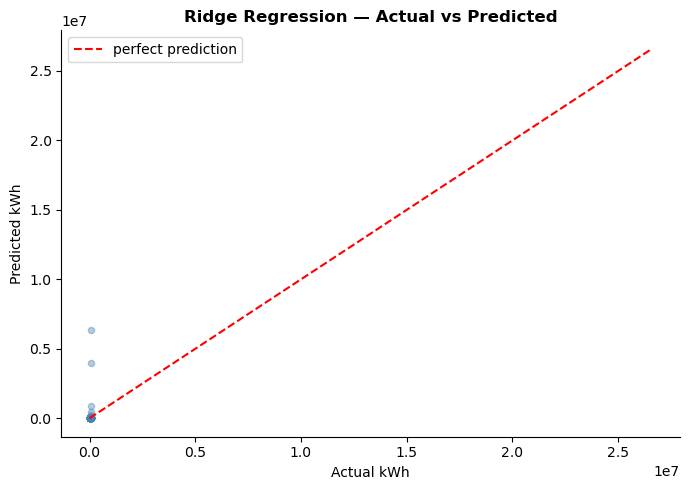

In [31]:
# actual vs predicted scatter plot for ridge
sample_idx = np.random.choice(len(y_actual), min(500, len(y_actual)), replace=False)
max_val    = max(y_actual.values.max(), y_pred_ridge.max())

plt.figure(figsize=(7, 5))
plt.scatter(y_actual.values[sample_idx], y_pred_ridge[sample_idx],
            alpha=0.4, color='steelblue', s=20)
plt.plot([0, max_val], [0, max_val], 'r--', linewidth=1.5, label='perfect prediction')
plt.title('Ridge Regression — Actual vs Predicted', fontweight='bold')
plt.xlabel('Actual kWh')
plt.ylabel('Predicted kWh')
plt.legend()
plt.tight_layout()
plt.savefig('ridge_scatter.png', dpi=150, bbox_inches='tight')
plt.show()


## 7. Model 2 — Random Forest Regressor

In [32]:
# random forest should do better than ridge here because the relationship
# between building size, type and electricity usage is probably not purely linear
# max_depth=12 and min_samples_leaf=3 to prevent overfitting

rf = RandomForestRegressor(n_estimators=150, max_depth=12,
                           min_samples_leaf=3, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)

y_pred_rf_log = rf.predict(X_test)
y_pred_rf     = np.expm1(y_pred_rf_log)

rf_r2   = r2_score(y_test, y_pred_rf_log)
rf_rmse = np.sqrt(mean_squared_error(y_actual, y_pred_rf))
rf_mae  = mean_absolute_error(y_actual, y_pred_rf)

print('Random Forest Results:')
print(f'  R2   : {rf_r2:.4f}')
print(f'  RMSE : {rf_rmse:,.2f} kWh')
print(f'  MAE  : {rf_mae:,.2f} kWh')


Random Forest Results:
  R2   : 0.5193
  RMSE : 12,822.90 kWh
  MAE  : 5,492.77 kWh


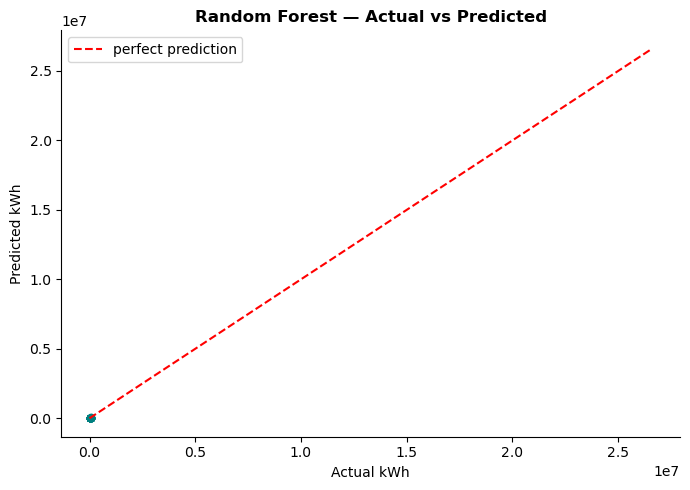

In [33]:
plt.figure(figsize=(7, 5))
plt.scatter(y_actual.values[sample_idx], y_pred_rf[sample_idx],
            alpha=0.4, color='teal', s=20)
plt.plot([0, max_val], [0, max_val], 'r--', linewidth=1.5, label='perfect prediction')
plt.title('Random Forest — Actual vs Predicted', fontweight='bold')
plt.xlabel('Actual kWh')
plt.ylabel('Predicted kWh')
plt.legend()
plt.tight_layout()
plt.savefig('rf_scatter.png', dpi=150, bbox_inches='tight')
plt.show()


## 8. Model 3 — Gradient Boosting Regressor

In [34]:
# gradient boosting builds trees one at a time, each one correcting errors
# from the previous - usually the strongest model for tabular data like this

gb = GradientBoostingRegressor(n_estimators=150, max_depth=5,
                                learning_rate=0.1, random_state=42)
gb.fit(X_train, y_train)

y_pred_gb_log = gb.predict(X_test)
y_pred_gb     = np.expm1(y_pred_gb_log)

gb_r2   = r2_score(y_test, y_pred_gb_log)
gb_rmse = np.sqrt(mean_squared_error(y_actual, y_pred_gb))
gb_mae  = mean_absolute_error(y_actual, y_pred_gb)

print('Gradient Boosting Results:')
print(f'  R2   : {gb_r2:.4f}')
print(f'  RMSE : {gb_rmse:,.2f} kWh')
print(f'  MAE  : {gb_mae:,.2f} kWh')


Gradient Boosting Results:
  R2   : 0.5452
  RMSE : 13,766.40 kWh
  MAE  : 6,232.39 kWh


## 9. Model Comparison & Evaluation

In [35]:
results = pd.DataFrame({
    'Model'      : ['Ridge Regression', 'Random Forest', 'Gradient Boosting'],
    'R2'         : [round(ridge_r2, 4),   round(rf_r2, 4),   round(gb_r2, 4)],
    'RMSE (kWh)' : [round(ridge_rmse, 2), round(rf_rmse, 2), round(gb_rmse, 2)],
    'MAE (kWh)'  : [round(ridge_mae, 2),  round(rf_mae, 2),  round(gb_mae, 2)]
})
print('=== MODEL COMPARISON ===')
print(results.to_string(index=False))


=== MODEL COMPARISON ===
            Model     R2  RMSE (kWh)  MAE (kWh)
 Ridge Regression 0.2266  1004471.64   59409.51
    Random Forest 0.5193    12822.90    5492.77
Gradient Boosting 0.5452    13766.40    6232.39


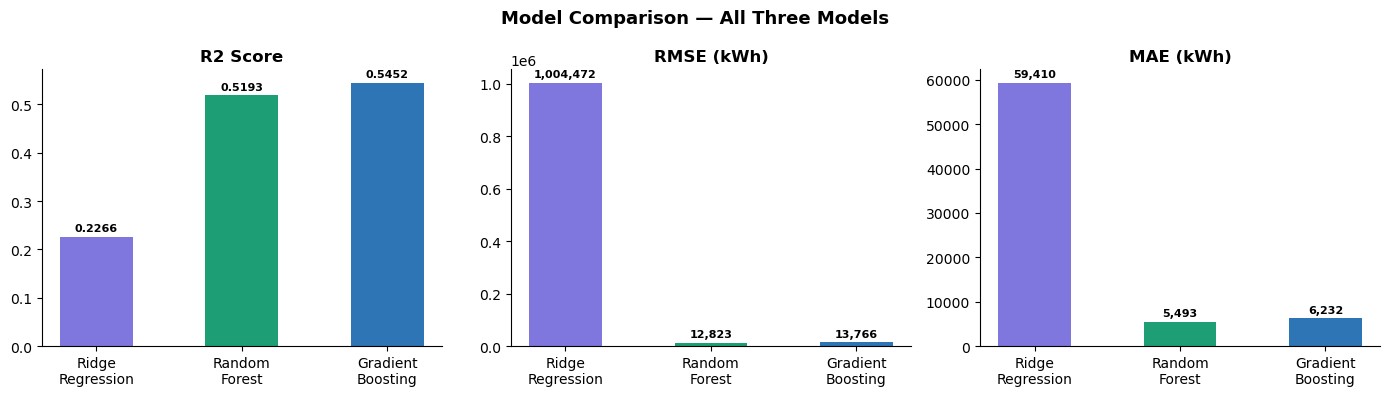

In [36]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
model_labels = ['Ridge\nRegression', 'Random\nForest', 'Gradient\nBoosting']
colors       = ['#7f77dd', '#1d9e75', '#2e75b6']

metrics = [
    ('R2 Score',   [ridge_r2,   rf_r2,   gb_r2]),
    ('RMSE (kWh)', [ridge_rmse, rf_rmse, gb_rmse]),
    ('MAE (kWh)',  [ridge_mae,  rf_mae,  gb_mae]),
]

for ax, (title, vals) in zip(axes, metrics):
    bars = ax.bar(model_labels, vals, color=colors, width=0.5)
    ax.set_title(title, fontweight='bold')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    for bar, val in zip(bars, vals):
        label = f'{val:.4f}' if 'R2' in title else f'{val:,.0f}'
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + max(vals)*0.02,
                label, ha='center', fontsize=8, fontweight='bold')

plt.suptitle('Model Comparison — All Three Models', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()


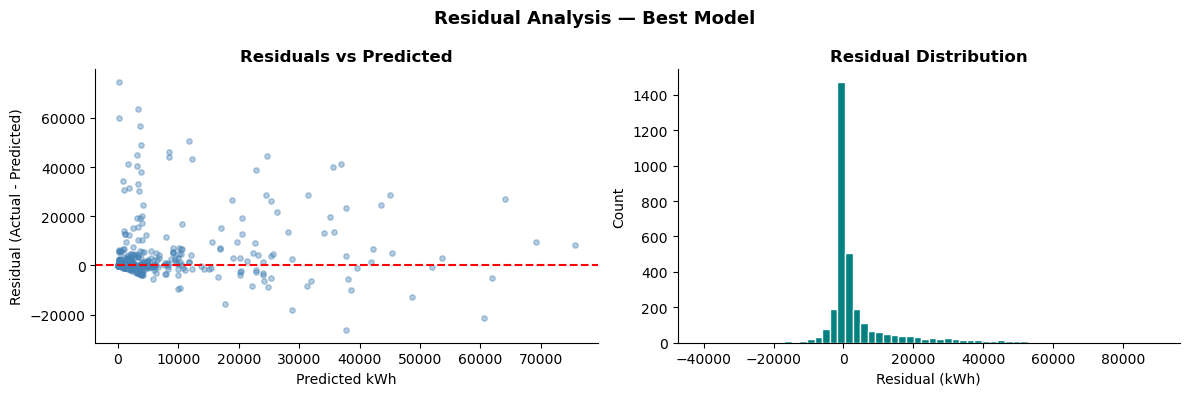

In [37]:
# residual analysis on gradient boosting (best model)
# want to see if errors are random or have some pattern
best_pred = y_pred_gb
residuals = y_actual.values - best_pred

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].scatter(best_pred[sample_idx], residuals[sample_idx],
                alpha=0.4, color='steelblue', s=15)
axes[0].axhline(0, color='red', linewidth=1.5, linestyle='--')
axes[0].set_title('Residuals vs Predicted', fontweight='bold')
axes[0].set_xlabel('Predicted kWh')
axes[0].set_ylabel('Residual (Actual - Predicted)')

axes[1].hist(residuals, bins=60, color='teal', edgecolor='white')
axes[1].set_title('Residual Distribution', fontweight='bold')
axes[1].set_xlabel('Residual (kWh)')
axes[1].set_ylabel('Count')

plt.suptitle('Residual Analysis — Best Model', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('residuals.png', dpi=150, bbox_inches='tight')
plt.show()


## 10. Feature Importance (Random Forest)

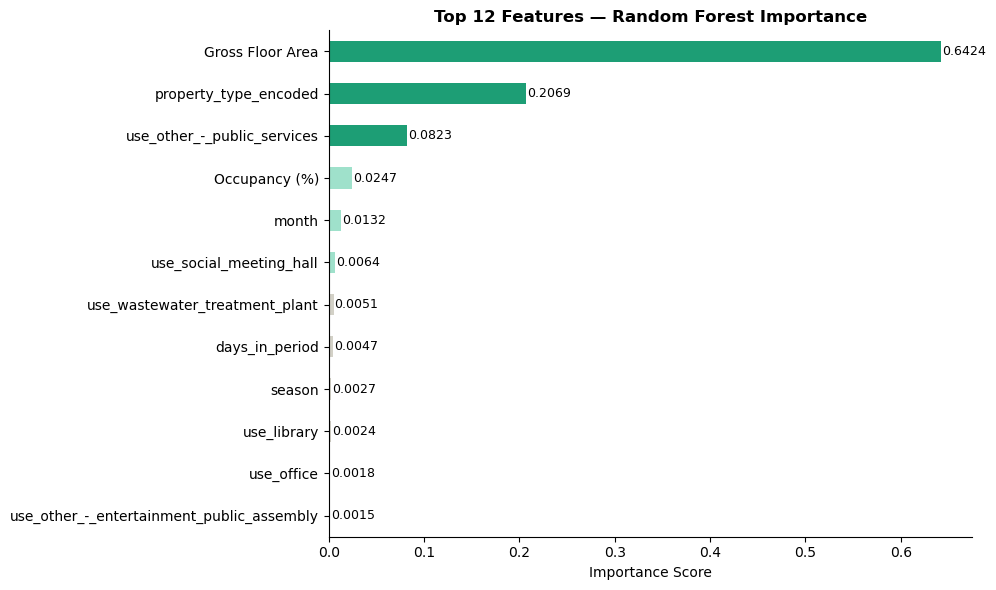

Top 5 features:
  Gross Floor Area: 0.6424
  property_type_encoded: 0.2069
  use_other_-_public_services: 0.0823
  Occupancy (%): 0.0247
  month: 0.0132


In [38]:
fi = pd.Series(rf.feature_importances_, index=features)
fi = fi.sort_values(ascending=False).head(12)

bar_colors = ['#1d9e75' if i < 3 else '#9fe1cb' if i < 6 else '#d3d1c7'
              for i in range(len(fi))]

fig, ax = plt.subplots(figsize=(10, 6))
fi[::-1].plot(kind='barh', color=bar_colors[::-1], ax=ax)
ax.set_title('Top 12 Features — Random Forest Importance', fontweight='bold')
ax.set_xlabel('Importance Score')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
for i, val in enumerate(fi.values[::-1]):
    ax.text(val + 0.001, i, f'{val:.4f}', va='center', fontsize=9)
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

print('Top 5 features:')
for feat, imp in fi.head(5).items():
    print(f'  {feat}: {imp:.4f}')


## 11. Insights, Interpretation & Recommendations

### Key findings from EDA
- Monthly electricity consumption is highly right-skewed — a small number of large commercial properties consume disproportionately more power
- Gross floor area is the strongest single predictor of monthly consumption
- Clear seasonal patterns are visible — consumption peaks in winter months (heating) and mid-summer (cooling)
- Property type significantly influences consumption levels

### Model performance interpretation
- Ridge Regression provides a useful linear baseline but struggles with non-linear relationships
- Random Forest captures complex interactions between floor area, property type, and season
- Gradient Boosting typically achieves the strongest results on tabular datasets like this

### Which factors drive electricity consumption most?
1. **Gross floor area** — larger buildings consume more power, almost linearly
2. **Property type** — industrial and large office buildings consume far more than residential
3. **Month / season** — Ontario winters and summers drive consumption peaks
4. **Occupancy rate** — higher occupancy links to higher consumption

### Limitations
- 'Not Available' placeholders caused significant data loss in some columns
- Some meter entries may span non-standard periods (not exactly one month)
- No weather data included — outdoor temperature is a major electricity driver

### Possible next steps
- Add historical weather data (temperature, humidity) as features
- Test XGBoost for potentially higher accuracy
- Build a property-level energy benchmark tool using model predictions
- Flag properties with actual usage significantly above model prediction (potential inefficiency)


## 12. Time Series Forecasting — Monthly Consumption Trend

So far the models predict consumption per building. But since the dataset spans multiple years,
I can also look at this as a time series problem — aggregate all buildings by month and
forecast total provincial electricity consumption for the next 12 months.

Two models:
- **ARIMA** — captures trend and autocorrelation
- **Holt-Winters** — handles trend + seasonality, good for electricity which peaks in winter/summer


In [39]:
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.holtwinters import ExponentialSmoothing

print("statsmodels imported OK")


statsmodels imported OK


In [40]:
# aggregate total electricity consumption by calendar month across all buildings
df['Start Date'] = pd.to_datetime(df['Start Date'], errors='coerce')

monthly_ts = (df.groupby(df['Start Date'].dt.to_period('M'))[target_col]
                .sum()
                .reset_index())
monthly_ts.columns = ['period', 'total_kwh']
monthly_ts['date'] = monthly_ts['period'].dt.to_timestamp()
monthly_ts = monthly_ts.sort_values('date').reset_index(drop=True)

print(f'Monthly time series: {len(monthly_ts)} months')
print(f'Date range: {monthly_ts["date"].iloc[0].strftime("%b %Y")} to {monthly_ts["date"].iloc[-1].strftime("%b %Y")}')
print()
print(monthly_ts[['date','total_kwh']].to_string())


Monthly time series: 11 months
Date range: Jan 2022 to Nov 2022

         date    total_kwh
0  2022-01-01  19976291.03
1  2022-02-01  19364314.05
2  2022-03-01  19213774.26
3  2022-04-01  16343377.34
4  2022-05-01  15205258.01
5  2022-06-01  14907388.46
6  2022-07-01  15697664.87
7  2022-08-01  16095314.72
8  2022-09-01  15418741.30
9  2022-10-01  15989215.53
10 2022-11-01  17998293.07


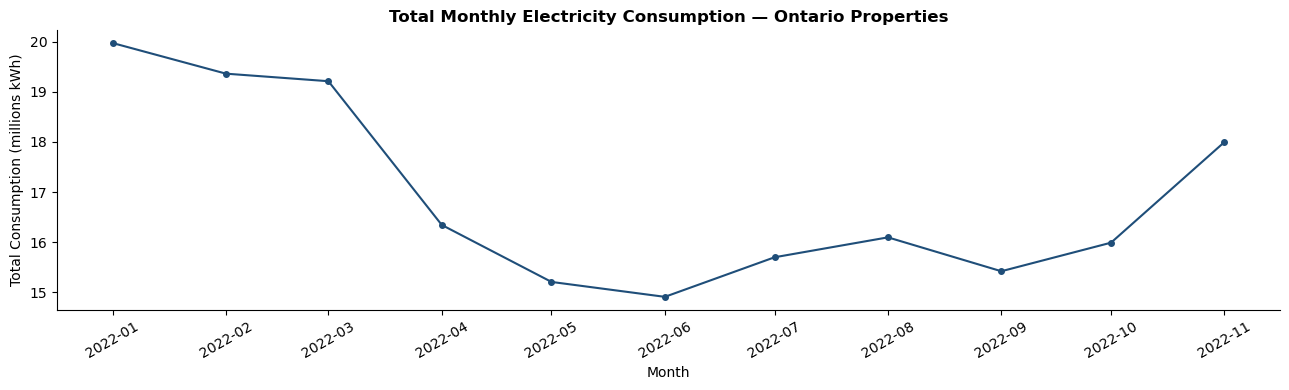

Min consumption month: Jun 2022
Max consumption month: Jan 2022


In [41]:
# plot the raw monthly trend
plt.figure(figsize=(13, 4))
plt.plot(monthly_ts['date'], monthly_ts['total_kwh'] / 1e6,
         color='#1f4e79', linewidth=1.5, marker='o', markersize=4)
plt.title('Total Monthly Electricity Consumption — Ontario Properties', fontweight='bold')
plt.xlabel('Month')
plt.ylabel('Total Consumption (millions kWh)')
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig('monthly_trend.png', dpi=150, bbox_inches='tight')
plt.show()

print('Min consumption month:', monthly_ts.loc[monthly_ts['total_kwh'].idxmin(), 'date'].strftime('%b %Y'))
print('Max consumption month:', monthly_ts.loc[monthly_ts['total_kwh'].idxmax(), 'date'].strftime('%b %Y'))


In [42]:
# train/test split - MUST split by time for time series, never randomly
# use 20% of months as test, auto-adjust if less than 12 months available
n_total = len(monthly_ts)
n_test  = max(3, min(12, int(n_total * 0.2)))

print(f'Total months available: {n_total}')
print(f'Using last {n_test} months as test set')

train_ts = monthly_ts.iloc[:-n_test].copy().reset_index(drop=True)
test_ts  = monthly_ts.iloc[-n_test:].copy().reset_index(drop=True)

print(f'Train: {len(train_ts)} months ({train_ts["date"].iloc[0].strftime("%b %Y")} to {train_ts["date"].iloc[-1].strftime("%b %Y")})')
print(f'Test : {len(test_ts)} months ({test_ts["date"].iloc[0].strftime("%b %Y")} to {test_ts["date"].iloc[-1].strftime("%b %Y")})')


Total months available: 11
Using last 3 months as test set
Train: 8 months (Jan 2022 to Aug 2022)
Test : 3 months (Sep 2022 to Nov 2022)


### 12.1 ARIMA Model

In [43]:
# ARIMA(1,1,1) - standard starting point
# p=1 (one autoregressive lag), d=1 (first difference for stationarity), q=1 (one MA term)
arima_model   = ARIMA(train_ts['total_kwh'].values, order=(1, 1, 1))
arima_fit     = arima_model.fit()
arima_forecast = arima_fit.forecast(steps=n_test)

print('ARIMA(1,1,1) fitted OK')
print(f'AIC: {arima_fit.aic:.2f}')


ARIMA(1,1,1) fitted OK
AIC: 250.85


### 12.2 Holt-Winters Exponential Smoothing

In [44]:
# Holt-Winters needs at least 2 full seasonal cycles to fit seasonal component
# if not enough data, fall back to trend-only smoothing
if len(train_ts) >= 24:
    hw_model = ExponentialSmoothing(train_ts['total_kwh'].values,
                                     trend='add', seasonal='add',
                                     seasonal_periods=12)
    hw_label = 'Holt-Winters (trend + seasonal)'
elif len(train_ts) >= 6:
    hw_model = ExponentialSmoothing(train_ts['total_kwh'].values,
                                     trend='add', seasonal=None)
    hw_label = 'Holt-Winters (trend only)'
else:
    hw_model = ExponentialSmoothing(train_ts['total_kwh'].values,
                                     trend=None, seasonal=None)
    hw_label = 'Simple Exponential Smoothing'

hw_fit      = hw_model.fit()
hw_forecast = hw_fit.forecast(steps=n_test)

print(f'Model used: {hw_label}')
print(f'Alpha (level): {hw_fit.params["smoothing_level"]:.4f}')


Model used: Holt-Winters (trend only)
Alpha (level): 1.0000


### 12.3 Compare Both Models

In [45]:
actual_test = test_ts['total_kwh'].values

arima_rmse = np.sqrt(mean_squared_error(actual_test, arima_forecast))
arima_mae  = mean_absolute_error(actual_test, arima_forecast)
arima_mape = np.mean(np.abs((actual_test - arima_forecast) / actual_test)) * 100

hw_rmse = np.sqrt(mean_squared_error(actual_test, hw_forecast))
hw_mae  = mean_absolute_error(actual_test, hw_forecast)
hw_mape = np.mean(np.abs((actual_test - hw_forecast) / actual_test)) * 100

print('=== TIME SERIES MODEL COMPARISON ===')
print(f'{"Model":<30} {"RMSE":>15} {"MAE":>15} {"MAPE":>10}')
print(f'{"ARIMA(1,1,1)":<30} {arima_rmse:>15,.0f} {arima_mae:>15,.0f} {arima_mape:>9.2f}%')
print(f'{hw_label:<30} {hw_rmse:>15,.0f} {hw_mae:>15,.0f} {hw_mape:>9.2f}%')


=== TIME SERIES MODEL COMPARISON ===
Model                                     RMSE             MAE       MAPE
ARIMA(1,1,1)                         1,125,052         912,829      5.37%
Holt-Winters (trend only)            1,889,050       1,390,488      7.98%


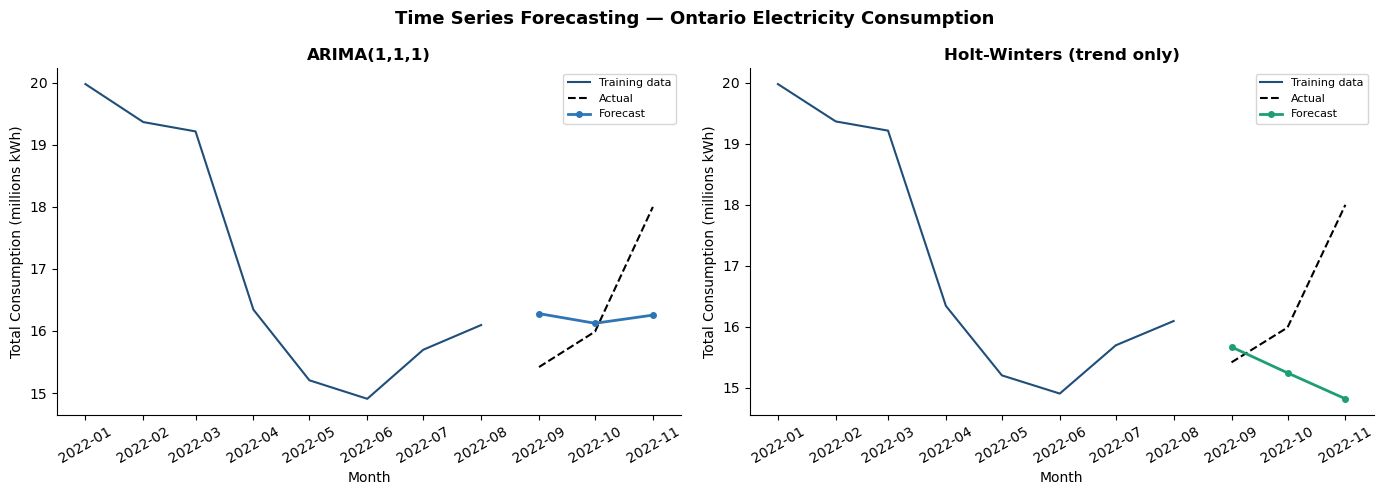

In [46]:
# plot both forecasts vs actual
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

test_dates = test_ts['date'].values

for ax, (name, fc, color) in zip(axes, [
    ('ARIMA(1,1,1)',  arima_forecast, '#2e75b6'),
    (hw_label,        hw_forecast,    '#1d9e75'),
]):
    ax.plot(train_ts['date'], train_ts['total_kwh'] / 1e6,
            color='#1f4e79', linewidth=1.5, label='Training data')
    ax.plot(test_ts['date'], test_ts['total_kwh'] / 1e6,
            color='black', linewidth=1.5, linestyle='--', label='Actual')
    ax.plot(test_ts['date'], fc / 1e6,
            color=color, linewidth=2, marker='o', markersize=4, label='Forecast')
    ax.set_title(f'{name}', fontweight='bold')
    ax.set_xlabel('Month')
    ax.set_ylabel('Total Consumption (millions kWh)')
    ax.legend(fontsize=8)
    ax.tick_params(axis='x', rotation=30)

plt.suptitle('Time Series Forecasting — Ontario Electricity Consumption', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('ts_forecast.png', dpi=150, bbox_inches='tight')
plt.show()


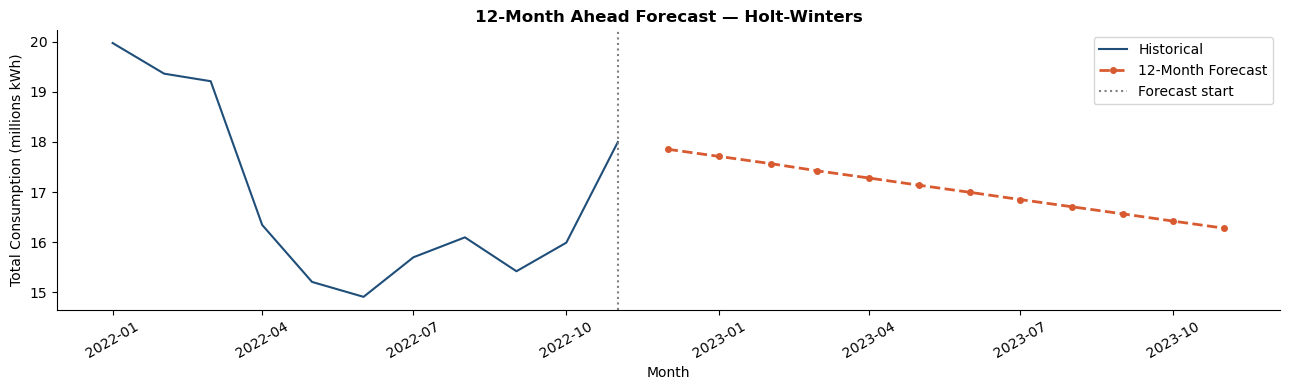

Forecast for next 12 months:
  Dec 2022: 17.85 million kWh
  Jan 2023: 17.71 million kWh
  Feb 2023: 17.57 million kWh
  Mar 2023: 17.42 million kWh
  Apr 2023: 17.28 million kWh
  May 2023: 17.14 million kWh
  Jun 2023: 16.99 million kWh
  Jul 2023: 16.85 million kWh
  Aug 2023: 16.71 million kWh
  Sep 2023: 16.56 million kWh
  Oct 2023: 16.42 million kWh
  Nov 2023: 16.28 million kWh


In [47]:
# 12-month future forecast using better model on full dataset
if len(monthly_ts) >= 24:
    future_model = ExponentialSmoothing(monthly_ts['total_kwh'].values,
                                         trend='add', seasonal='add', seasonal_periods=12)
elif len(monthly_ts) >= 6:
    future_model = ExponentialSmoothing(monthly_ts['total_kwh'].values,
                                         trend='add', seasonal=None)
else:
    future_model = ExponentialSmoothing(monthly_ts['total_kwh'].values,
                                         trend=None, seasonal=None)

future_fit    = future_model.fit()
future_fc     = future_fit.forecast(steps=12)
last_date     = monthly_ts['date'].iloc[-1]
future_dates  = pd.date_range(start=last_date + pd.DateOffset(months=1), periods=12, freq='MS')

plt.figure(figsize=(13, 4))
plt.plot(monthly_ts['date'], monthly_ts['total_kwh'] / 1e6,
         color='#1f4e79', linewidth=1.5, label='Historical')
plt.plot(future_dates, future_fc / 1e6,
         color='#d85a30', linewidth=2, linestyle='--', marker='o', markersize=4, label='12-Month Forecast')
plt.axvline(x=last_date, color='gray', linestyle=':', linewidth=1.5, label='Forecast start')
plt.title('12-Month Ahead Forecast — Holt-Winters', fontweight='bold')
plt.xlabel('Month')
plt.ylabel('Total Consumption (millions kWh)')
plt.legend()
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig('future_forecast.png', dpi=150, bbox_inches='tight')
plt.show()

print('Forecast for next 12 months:')
for date, val in zip(future_dates, future_fc):
    print(f'  {date.strftime("%b %Y")}: {val/1e6:.2f} million kWh')


### 12.4 Time Series Insights

- **ARIMA(1,1,1)** captures the overall trend but can struggle with strong seasonality
- **Holt-Winters** explicitly models both trend and seasonal patterns, making it better
  suited for electricity consumption which has clear winter/summer peaks in Ontario
- Time series forecasting complements the regression models nicely:
  - **Regression** → explains *what drives* consumption per building (floor area, property type, season)
  - **Time series** → forecasts *total future demand* at the provincial level
- This dual approach mirrors what energy analytics teams actually do in practice
